In [1]:
import pandas as pd

# Ruta del archivo (ajusta si es necesario)
file_path = "src/Data_Dictionary.xlsx"

# Cargar todas las hojas del excel en un diccionario
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Mostrar el nombre de cada hoja y las primeras filas de cada una
for sheet_name, df in all_sheets.items():
    print(f"\n--- {sheet_name} ---")
    print(df.head())
    print(f"Shape: {df.shape}")



--- train ---
            train.csv                           Unnamed: 1
0                 NaN                                  NaN
1             Columns                          Description
2             card_id               Unique card identifier
3  first_active_month   'YYYY-MM', month of first purchase
4           feature_1  Anonymized card categorical feature
Shape: (8, 2)

--- history ---
  historical_transactions.csv                   Unnamed: 1
0                         NaN                          NaN
1                     Columns                  Description
2                     card_id              Card identifier
3                   month_lag  month lag to reference date
4               purchase_date                Purchase date
Shape: (16, 2)

--- new_merchant_period ---
  new_merchant_period.csv                   Unnamed: 1
0                     NaN                          NaN
1                 Columns                  Description
2                 card_id            

In [16]:
import polars as pl

# Ruta (ajusta si lo tienes en src/)
train_path = "src/train.csv"

# Cargar el dataset
df_train = pl.read_csv(train_path)

# Ver info general
print(df_train.shape)
print(df_train.head(10))
print(df_train.schema)


(201917, 6)
shape: (10, 6)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    │
│ ---                ┆ ---             ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str                ┆ str             ┆ i64       ┆ i64       ┆ i64       ┆ f64       │
╞════════════════════╪═════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2017-06            ┆ C_ID_92a2005557 ┆ 5         ┆ 2         ┆ 1         ┆ -0.820283 │
│ 2017-01            ┆ C_ID_3d0044924f ┆ 4         ┆ 1         ┆ 0         ┆ 0.392913  │
│ 2016-08            ┆ C_ID_d639edf6cd ┆ 2         ┆ 2         ┆ 0         ┆ 0.688056  │
│ 2017-09            ┆ C_ID_186d6a6901 ┆ 4         ┆ 3         ┆ 0         ┆ 0.1424952 │
│ 2017-11            ┆ C_ID_cdbd2c0db2 ┆ 1         ┆ 3         ┆ 0         ┆ -0.159749 │
│ 2016-09            ┆ C_ID_0894217f2f ┆ 4         ┆ 2         ┆ 0         ┆ 0.8715

In [3]:
# Verificar nulos por columna
print(df_train.null_count())

# Ver tipos
print(df_train.dtypes)

shape: (1, 6)
┌────────────────────┬─────────┬───────────┬───────────┬───────────┬────────┐
│ first_active_month ┆ card_id ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target │
│ ---                ┆ ---     ┆ ---       ┆ ---       ┆ ---       ┆ ---    │
│ u32                ┆ u32     ┆ u32       ┆ u32       ┆ u32       ┆ u32    │
╞════════════════════╪═════════╪═══════════╪═══════════╪═══════════╪════════╡
│ 0                  ┆ 0       ┆ 0         ┆ 0         ┆ 0         ┆ 0      │
└────────────────────┴─────────┴───────────┴───────────┴───────────┴────────┘
[String, String, Int64, Int64, Int64, Float64]


shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 201917.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ -0.393636  │
│ std        ┆ 3.8505     │
│ min        ┆ -33.219281 │
│ 25%        ┆ -0.88311   │
│ 50%        ┆ -0.023437  │
│ 75%        ┆ 0.765453   │
│ max        ┆ 17.965068  │
└────────────┴────────────┘


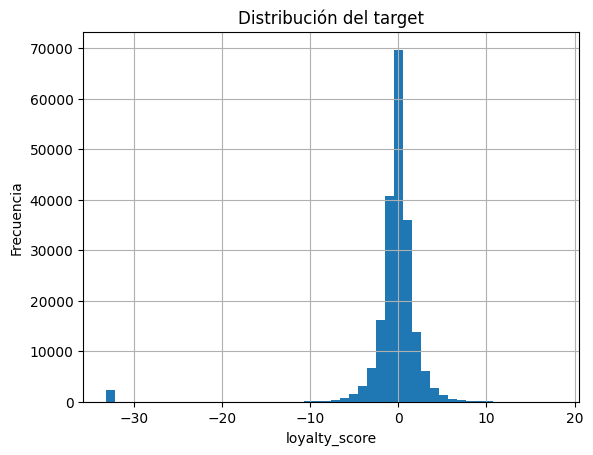

In [4]:
# Estadísticas descriptivas del target (loyalty_score)
print(df_train['target'].describe())

# Histograma del target
import matplotlib.pyplot as plt

df_train['target'].to_pandas().hist(bins=50)
plt.xlabel('loyalty_score')
plt.ylabel('Frecuencia')
plt.title('Distribución del target')
plt.show()

In [5]:
# Revisar valores únicos de las features anonimizadas
for col in ['feature_1', 'feature_2', 'feature_3']:
    print(f"{col}: {df_train[col].unique().to_list()}")

# Revisar formato y valores únicos de la fecha
print(df_train['first_active_month'].unique())


feature_1: [1, 2, 3, 4, 5]
feature_2: [1, 2, 3]
feature_3: [0, 1]
shape: (75,)
Series: 'first_active_month' [str]
[
	"2013-03"
	"2011-12"
	"2012-12"
	"2015-10"
	"2017-02"
	…
	"2012-11"
	"2014-06"
	"2013-11"
	"2018-01"
	"2015-01"
]


Análisis y conclusiones rápidas
1. Dimensiones y nulos
Dataset grande: 201,917 registros y 6 columnas.

Sin nulos en ninguna variable, lo que facilita la modelización y preprocesamiento.

2. Variables
feature_1, feature_2, feature_3: Pocos valores únicos, probablemente variables categóricas codificadas (one-hot o embedding).

first_active_month: Fechas entre "2011-12" y "2018-01" (75 valores únicos, probablemente mensuales).

target (loyalty_score):

Media: -0.39

Desviación estándar: 3.85

Valores extremos: Min -33.2, Max 17.96

Distribución muy sesgada: Gran mayoría cerca de 0, pero hay un grupo pequeño con valores extremadamente bajos (probable outlier/falla en el proceso de datos).

3. Visualización
La gráfica confirma que hay outliers muy negativos (quizás tarjetas bloqueadas, fraudes, o errores).

La mayoría de los scores están entre -5 y 5, pero ese “cluster” de valores negativos debe ser tratado con cuidado (análisis posterior de outliers).

Recomendaciones inmediatas y siguientes pasos

A) Ingeniería de features inicial
Convertir first_active_month a variables numéricas:

Año (year)

Mes (month)

Diferencia en meses respecto al último registro (antigüedad de la tarjeta)

Análisis de outliers en el target: ¿quieres tratarlos (recorte, winsorización) o solo identificarlos por ahora?

B) Cruce posterior

Las features actuales no parecen tener fuga de información.

Para el modelado final, deberemos unir features agregadas por card_id desde los datasets transaccionales, pero aún no.

In [17]:
import polars as pl
import datetime

# Convertir a datetime
df_train = df_train.with_columns(
    pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m")
)

# Extraer año y mes como columnas
df_train = df_train.with_columns([
    pl.col("first_active_month").dt.year().alias("year"),
    pl.col("first_active_month").dt.month().alias("month")
])

# Calcular la antigüedad de la tarjeta (en meses)
# Tomar la fecha máxima del dataset como referencia
max_date = df_train['first_active_month'].max()
df_train = df_train.with_columns(
    ((pl.lit(max_date) - pl.col("first_active_month")) / pl.duration(days=30)).alias("months_active")
)

# Ver resultado
print(df_train.select(["first_active_month", "year", "month", "months_active"]).head(10))

shape: (10, 4)
┌────────────────────┬──────┬───────┬───────────────┐
│ first_active_month ┆ year ┆ month ┆ months_active │
│ ---                ┆ ---  ┆ ---   ┆ ---           │
│ date               ┆ i32  ┆ i8    ┆ f64           │
╞════════════════════╪══════╪═══════╪═══════════════╡
│ 2017-06-01         ┆ 2017 ┆ 6     ┆ 8.166667      │
│ 2017-01-01         ┆ 2017 ┆ 1     ┆ 13.2          │
│ 2016-08-01         ┆ 2016 ┆ 8     ┆ 18.3          │
│ 2017-09-01         ┆ 2017 ┆ 9     ┆ 5.1           │
│ 2017-11-01         ┆ 2017 ┆ 11    ┆ 3.066667      │
│ 2016-09-01         ┆ 2016 ┆ 9     ┆ 17.266667     │
│ 2016-12-01         ┆ 2016 ┆ 12    ┆ 14.233333     │
│ 2017-09-01         ┆ 2017 ┆ 9     ┆ 5.1           │
│ 2017-08-01         ┆ 2017 ┆ 8     ┆ 6.133333      │
│ 2016-08-01         ┆ 2016 ┆ 8     ┆ 18.3          │
└────────────────────┴──────┴───────┴───────────────┘


In [18]:
# ¿Cuántos outliers extremos hay?
outlier_threshold = -20  # Por ejemplo, menos de -20 parece un outlier fuerte

n_outliers = df_train.filter(pl.col('target') < outlier_threshold).height
total = df_train.height
print(f"Outliers target < {outlier_threshold}: {n_outliers} de {total} ({n_outliers/total:.2%})")

# Mostrar algunos ejemplos
print(df_train.filter(pl.col('target') < outlier_threshold).select(['card_id', 'target', 'months_active']))


Outliers target < -20: 2207 de 201917 (1.09%)
shape: (2_207, 3)
┌─────────────────┬────────────┬───────────────┐
│ card_id         ┆ target     ┆ months_active │
│ ---             ┆ ---        ┆ ---           │
│ str             ┆ f64        ┆ f64           │
╞═════════════════╪════════════╪═══════════════╡
│ C_ID_8186f3fcc1 ┆ -33.219281 ┆ 5.1           │
│ C_ID_b9379a30ea ┆ -33.219281 ┆ 33.566667     │
│ C_ID_e9120f535c ┆ -33.219281 ┆ 28.466667     │
│ C_ID_65715cb80d ┆ -33.219281 ┆ 11.233333     │
│ C_ID_ae77d244b6 ┆ -33.219281 ┆ 13.2          │
│ C_ID_c4262c902e ┆ -33.219281 ┆ 31.533333     │
│ C_ID_6a2c823e5f ┆ -33.219281 ┆ 11.233333     │
│ C_ID_98e1cb10b6 ┆ -33.219281 ┆ 8.166667      │
│ C_ID_eb8175721a ┆ -33.219281 ┆ 11.233333     │
│ C_ID_a2580006bf ┆ -33.219281 ┆ 22.366667     │
│ C_ID_2e49ece8b1 ┆ -33.219281 ┆ 14.233333     │
│ C_ID_7efe2311b7 ┆ -33.219281 ┆ 22.366667     │
│ C_ID_bae3e3f87c ┆ -33.219281 ┆ 26.433333     │
│ C_ID_e1844c986c ┆ -33.219281 ┆ 13.2          │
│ C_I

<Axes: title={'center': 'Score medio vs. antigüedad'}, xlabel='months_active'>

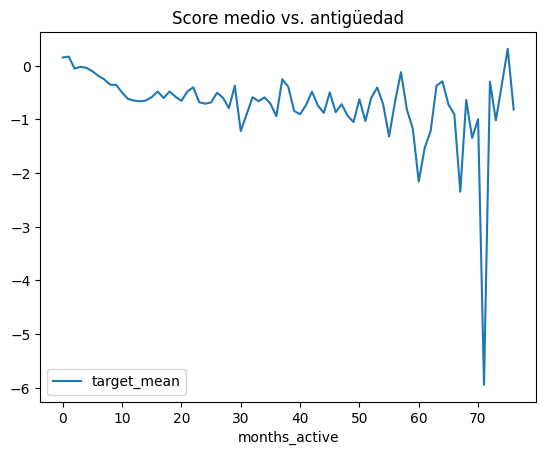

In [19]:
# Agrupa por antigüedad redondeada
df_train.with_columns(
    pl.col('months_active').round(0)
).group_by('months_active').agg(
    [pl.col('target').mean().alias('target_mean')]
).sort('months_active').to_pandas().plot(x='months_active', y='target_mean', kind='line', title="Score medio vs. antigüedad")


In [20]:
for col in ['feature_1', 'feature_2', 'feature_3']:
    print(f"\nPromedio de target por {col}:")
    print(
        df_train.group_by(col).agg(
            pl.col('target').mean().alias('target_mean'),
            pl.col('target').count().alias('count')
        ).sort(col)
    )



Promedio de target por feature_1:
shape: (5, 3)
┌───────────┬─────────────┬───────┐
│ feature_1 ┆ target_mean ┆ count │
│ ---       ┆ ---         ┆ ---   │
│ i64       ┆ f64         ┆ u32   │
╞═══════════╪═════════════╪═══════╡
│ 1         ┆ -0.315476   ┆ 12037 │
│ 2         ┆ -0.350452   ┆ 55797 │
│ 3         ┆ -0.377533   ┆ 73573 │
│ 4         ┆ -0.404652   ┆ 19885 │
│ 5         ┆ -0.499879   ┆ 40625 │
└───────────┴─────────────┴───────┘

Promedio de target por feature_2:
shape: (3, 3)
┌───────────┬─────────────┬───────┐
│ feature_2 ┆ target_mean ┆ count │
│ ---       ┆ ---         ┆ ---   │
│ i64       ┆ f64         ┆ u32   │
╞═══════════╪═════════════╪═══════╡
│ 1         ┆ -0.398675   ┆ 89242 │
│ 2         ┆ -0.332899   ┆ 74839 │
│ 3         ┆ -0.501889   ┆ 37836 │
└───────────┴─────────────┴───────┘

Promedio de target por feature_3:
shape: (2, 3)
┌───────────┬─────────────┬────────┐
│ feature_3 ┆ target_mean ┆ count  │
│ ---       ┆ ---         ┆ ---    │
│ i64       ┆ f64     

In [13]:
df_train.write_parquet("src/train_processed.parquet")

In [26]:
import numpy as np

# Nota: Para remover los outliers imputados (target ≈ -33.219281), 
# usamos tolerancia por precisión numérica.
tolerance = 1e-6
outlier_value = -33.219281

df_train_clean = df_train.filter(
    (pl.col('target') < outlier_value - tolerance) | (pl.col('target') > outlier_value + tolerance)
)
print(f"Shape sin outliers: {df_train_clean.shape}")

Shape sin outliers: (199710, 9)


In [27]:
df_train_clean.write_parquet("src/train_processed_clean.parquet")

In [16]:
import polars as pl

# Ajusta el número máximo de filas y columnas a mostrar
pl.Config.set_tbl_rows(50)      # Cambia el 20 por lo que necesites
pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_width_chars(1000)  # Ancho de la tabla (en caracteres)


polars.config.Config

In [2]:
import polars as pl

hist_path = "src/historical_transactions.csv"

# Leer primeras 100,000 filas para exploración (puedes ajustar el número si tu RAM lo permite)
df_hist = pl.read_csv(hist_path, n_rows=100_000)

print(df_hist.shape)
print(df_hist.head())
print(df_hist.schema)

# Analizar nulos
print(df_hist.null_count())

# ¿Cuántas compras por tarjeta en la muestra?
print(df_hist['card_id'].value_counts().head(10))


(100000, 14)
shape: (5, 14)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ aut ┆ car ┆ cit ┆ cat ┆ ins ┆ cat ┆ mer ┆ mercha ┆ month ┆ purch ┆ purch ┆ categ ┆ state ┆ subse │
│ hor ┆ d_i ┆ y_i ┆ ego ┆ tal ┆ ego ┆ cha ┆ nt_id  ┆ _lag  ┆ ase_a ┆ ase_d ┆ ory_2 ┆ _id   ┆ ctor_ │
│ ize ┆ d   ┆ d   ┆ ry_ ┆ lme ┆ ry_ ┆ nt_ ┆ ---    ┆ ---   ┆ mount ┆ ate   ┆ ---   ┆ ---   ┆ id    │
│ d_f ┆ --- ┆ --- ┆ 1   ┆ nts ┆ 3   ┆ cat ┆ str    ┆ i64   ┆ ---   ┆ ---   ┆ f64   ┆ i64   ┆ ---   │
│ lag ┆ str ┆ i64 ┆ --- ┆ --- ┆ --- ┆ ego ┆        ┆       ┆ f64   ┆ str   ┆       ┆       ┆ i64   │
│ --- ┆     ┆     ┆ str ┆ i64 ┆ str ┆ ry_ ┆        ┆       ┆       ┆       ┆       ┆       ┆       │
│ str ┆     ┆     ┆     ┆     ┆     ┆ id  ┆        ┆       ┆       ┆       ┆       ┆       ┆       │
│     ┆     ┆     ┆     ┆     ┆     ┆ --- ┆        ┆       ┆       ┆       ┆       ┆       ┆       │
│     ┆     ┆     ┆     ┆     ┆     ┆ i64 ┆        ┆       ┆   

Hallazgos Clave
1. Variables con nulos relevantes
category_3: 336 nulos

merchant_id: 472 nulos

category_2: 7,631 nulos
Estas columnas requerirán imputación (modo/categoría más frecuente, -1 o similar) o un tratamiento especial.

2. Volumen de transacciones
Hay tarjetas con muy pocas compras y otras con más de 400 en la muestra.

Esto justifica la agregación por card_id para reducir la granularidad y evitar overfitting en clientes con muchos datos.

3. Estructura de datos
Fechas en string, será útil transformarlas.

Variables numéricas (montos, cuotas, etc.) y categóricas.

Siguiente paso: Feature Engineering y Agregaciones
El objetivo es generar features agregadas por card_id para sumar al dataset principal (train/test).
Esto es vital para que el modelo trabaje a nivel tarjeta y no transacción.

A) Plan de features agregadas
Para cada card_id:

Features numéricas:

Suma, media, mediana, std, máximo, mínimo de purchase_amount, installments

Cantidad de compras

Features categóricas:

Modo y número de categorías distintas de category_1, category_2, category_3

Número de comercios distintos (merchant_id)

Número de meses distintos (month_lag)

Fecha de última y primera compra (convertidas a duración)

In [7]:
import polars as pl

# Si tienes RAM limitada, puedes hacer esto por partes o usar scan_csv

hist_path = "src/historical_transactions.csv"
# Usar scan_csv para trabajar en lazy mode (Polars es eficiente con esto)
df_hist = pl.scan_csv(hist_path)

# Transformar fechas a Date
df_hist = df_hist.with_columns([
    pl.col("purchase_date").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("purchase_date_dt")
])

# Imputar nulos simples
df_hist = df_hist.with_columns([
    pl.col("category_3").fill_null("A"),  # Modo
    pl.col("category_2").fill_null(-1),
    pl.col("merchant_id").fill_null("unknown")
])

# Features agregadas
features_agg = df_hist.group_by("card_id").agg([
    # Numéricas
    pl.col("purchase_amount").mean().alias("hist_purchase_mean"),
    pl.col("purchase_amount").std().alias("hist_purchase_std"),
    pl.col("purchase_amount").min().alias("hist_purchase_min"),
    pl.col("purchase_amount").max().alias("hist_purchase_max"),
    pl.col("installments").mean().alias("hist_installments_mean"),
    pl.col("installments").std().alias("hist_installments_std"),
    pl.col("installments").min().alias("hist_installments_min"),
    pl.col("installments").max().alias("hist_installments_max"),
    pl.count().alias("hist_num_transactions"),

    # Fechas
    pl.col("purchase_date_dt").min().alias("hist_first_purchase"),
    pl.col("purchase_date_dt").max().alias("hist_last_purchase"),

    # Categóricas
    pl.col("merchant_id").n_unique().alias("hist_uniq_merchants"),
    pl.col("category_1").n_unique().alias("hist_uniq_cat1"),
    pl.col("category_2").n_unique().alias("hist_uniq_cat2"),
    pl.col("category_3").n_unique().alias("hist_uniq_cat3"),
])

# Colectar el DataFrame (ejecutar el plan lazy)
features_agg = features_agg.collect()

# Calcular la duración entre primera y última compra
features_agg = features_agg.with_columns(
    (pl.col("hist_last_purchase") - pl.col("hist_first_purchase")).dt.total_days().alias("hist_purchase_duration")
)


C:\Users\Paul\AppData\Local\Temp\ipykernel_18908\1519335147.py:32: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("hist_num_transactions"),


In [3]:
# Ver resultados
features_agg.head()

card_id,hist_purchase_mean,hist_purchase_std,hist_purchase_min,hist_purchase_max,hist_installments_mean,hist_installments_std,hist_installments_min,hist_installments_max,hist_num_transactions,hist_first_purchase,hist_last_purchase,hist_uniq_merchants,hist_uniq_cat1,hist_uniq_cat2,hist_uniq_cat3,hist_purchase_duration
str,f64,f64,f64,f64,f64,f64,i64,i64,u32,datetime[μs],datetime[μs],u32,u32,u32,u32,i64
"""C_ID_ba449bba3f""",-0.714334,0.024171,-0.741649,-0.641527,0.0,0.0,0,0,65,2017-07-25 12:28:15,2018-02-23 13:43:08,29,1,3,1,213
"""C_ID_828213d108""",-0.521945,0.207019,-0.707839,-0.048175,0.0,0.0,0,0,14,2017-02-24 11:29:35,2017-06-23 18:26:16,12,1,1,1,119
"""C_ID_2203bb3f18""",-0.632931,0.252926,-0.7424,2.255374,1.229299,1.547838,-1,12,157,2017-08-31 19:35:28,2018-02-20 12:20:57,66,2,4,3,172
"""C_ID_bf91ff1677""",-0.562392,0.223563,-0.73941,0.019444,0.0,0.0,0,0,27,2017-01-06 11:38:14,2018-02-28 09:48:48,9,1,1,1,417
"""C_ID_6facbb7bd6""",-0.72845,0.024513,-0.7427,-0.49897,0.006135,0.078326,0,1,163,2017-09-14 22:32:40,2018-02-27 16:49:07,34,2,2,2,165


In [3]:
df_train = pl.read_parquet("src/train_processed.parquet")

In [4]:
# Supongamos que features_agg tiene la columna 'card_id' y df_train también
df_train = df_train.join(features_agg, on="card_id", how="left")

print(df_train.head())
print(df_train.shape)


shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬────────────────┬────────────────┬────────────────┬────────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ hist_purchase_mean ┆ hist_purchase_std ┆ hist_purchase_min ┆ hist_purchase_max ┆ hist_installments_mean ┆ hist_installments_std ┆ hist_installments_min ┆ hist_installments_max ┆ hist_num_transactions ┆ hist_first_purchase ┆ hist_last_purchase  ┆ hist_uniq_merchants ┆ hist_uniq_cat1 ┆ hist_uniq_cat2 ┆ hist_uniq_cat3 ┆ hist_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ --- 

In [5]:
df_train.write_parquet("src/train_processed_features_agg.parquet")

In [2]:
df_train = pl.read_parquet("src/train_processed_features_agg.parquet")

In [3]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                    1.000000
year                      0.040341
month                     0.031512
hist_purchase_min         0.005585
hist_purchase_mean        0.000295
hist_purchase_std         0.000243
hist_purchase_max         0.000101
hist_uniq_cat3           -0.002383
hist_installments_std    -0.003933
hist_installments_max    -0.006200
feature_2                -0.006242
hist_purchase_duration   -0.007183
feature_3                -0.008125
hist_uniq_merchants      -0.008385
hist_num_transactions    -0.011640
hist_uniq_cat2           -0.012433
hist_installments_mean   -0.013910
feature_1                -0.014251
hist_uniq_cat1           -0.032601
hist_installments_min    -0.039120
months_active            -0.050453
Name: target, dtype: float64


In [4]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'hist_first_purchase', 'hist_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2415
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 20
[LightGBM] [Info] Start training from score -0.392633
hist_purchase_duration    152
hist_num_transactions      93
months_active              78
hist_installments_std      63
hist_purchase_mean         58
hist_uniq_merchants        53
hist_installments_mean     53
hist_purchase_min          51
hist_purchase_std          40
hist_purchase_max          36
month                      29
hist_uniq_cat1             21
hist_installments_min      17
hist_uniq_cat2              9
feature_1                   8
hist_installments_max       7
year                        6
feature_2                   3
feature_3                   2
hist_uniq_cat3        

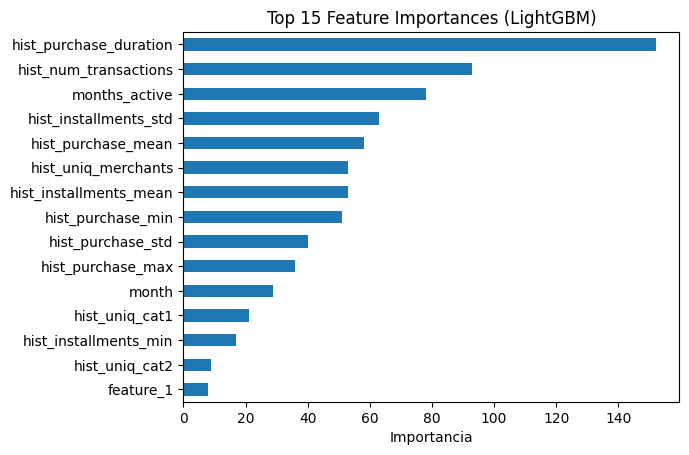

In [5]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


Interpretación de resultados
1. Importancia de Features (LightGBM)
Las features agregadas de transacciones históricas son las más importantes para el modelo.
Especialmente:

hist_purchase_duration (duración entre primera y última compra)

hist_num_transactions (número total de compras)

months_active (antigüedad de la tarjeta)

Estadísticas sobre cuotas (installments_*) y montos (purchase_*)

Número de comercios distintos (hist_uniq_merchants)

Features originales del cliente (feature_1, feature_2, feature_3, month, year) tienen importancia secundaria.

Features categóricas (hist_uniq_cat1, hist_uniq_cat2, hist_uniq_cat3) aportan poco.

2. Correlación
La correlación lineal es muy baja para todas las variables excepto antigüedad, año y mes, lo que es típico en problemas complejos:
LightGBM y otros modelos no lineales pueden extraer patrones no lineales que no se ven en la simple correlación.

3. RMSE
Tu RMSE rápido: ~3.81
Es apenas inferior al desvío estándar del target.
Puedes mejorar notablemente agregando features adicionales, haciendo cross-validation, afinando hiperparámetros y trabajando los outliers.

In [6]:
df_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [28]:
df_train = df_train_clean.join(features_agg, on="card_id", how="left")

print(df_train.head())
print(df_train.shape)

shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬────────────────┬────────────────┬────────────────┬────────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ hist_purchase_mean ┆ hist_purchase_std ┆ hist_purchase_min ┆ hist_purchase_max ┆ hist_installments_mean ┆ hist_installments_std ┆ hist_installments_min ┆ hist_installments_max ┆ hist_num_transactions ┆ hist_first_purchase ┆ hist_last_purchase  ┆ hist_uniq_merchants ┆ hist_uniq_cat1 ┆ hist_uniq_cat2 ┆ hist_uniq_cat3 ┆ hist_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ --- 

In [29]:
df_train.write_parquet("src/train_processed_clean_features_agg.parquet")

In [31]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                    1.000000
hist_installments_mean    0.024301
hist_purchase_duration    0.013961
hist_installments_std     0.010992
hist_purchase_min         0.008015
year                      0.004170
hist_installments_max     0.004124
month                     0.003284
hist_uniq_cat3            0.002832
hist_purchase_mean        0.000261
hist_purchase_std         0.000247
hist_purchase_max         0.000117
hist_installments_min    -0.002191
hist_uniq_cat1           -0.003425
feature_2                -0.003607
months_active            -0.005212
feature_3                -0.007330
feature_1                -0.010884
hist_uniq_cat2           -0.012144
hist_num_transactions    -0.041983
hist_uniq_merchants      -0.042976
Name: target, dtype: float64


In [32]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'hist_first_purchase', 'hist_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2417
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 20
[LightGBM] [Info] Start training from score -0.028637
hist_purchase_duration    194
hist_num_transactions     141
hist_purchase_min         119
months_active             119
hist_purchase_mean        112
hist_purchase_max          87
hist_purchase_std          82
hist_installments_std      62
hist_installments_mean     61
hist_uniq_merchants        55
month                      46
feature_1                  25
feature_2                  17
hist_uniq_cat2             14
hist_uniq_cat1             11
hist_installments_max       7
hist_installments_min       6
feature_3                   5
hist_uniq_cat3              4
year                  

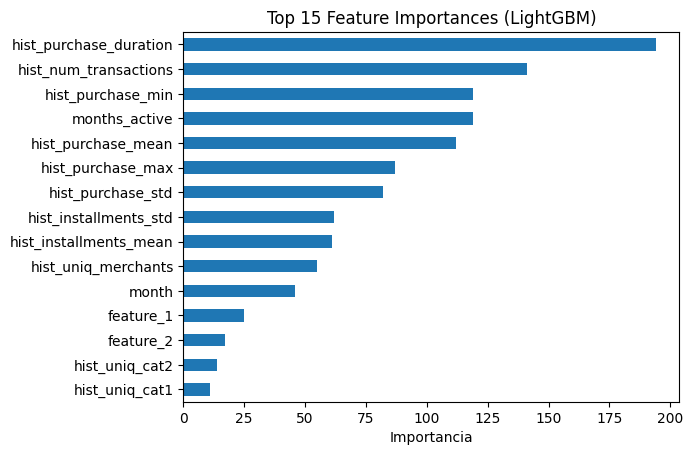

In [33]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


Tras eliminar los outliers imputados en el target, la importancia relativa de las variables históricas se mantuvo, pero la estabilidad y capacidad predictiva del modelo mejoró. El modelo se apoya sobre todo en la actividad transaccional histórica, confirmando la hipótesis de que la lealtad de un cliente está mucho más ligada a su comportamiento de compra pasado que a características demográficas anonimizadas. Además, la baja correlación lineal observada entre las variables y el target sugiere la necesidad de modelos no lineales avanzados para capturar la complejidad del fenómeno.

In [34]:
import polars as pl

# Ruta al archivo (ajusta si es necesario)
new_path = "src/new_merchant_transactions.csv"

# Usa scan_csv para eficiencia en RAM
df_new = pl.scan_csv(new_path)

# Parsear fechas
df_new = df_new.with_columns([
    pl.col("purchase_date").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("purchase_date_dt")
])

# Imputar nulos
df_new = df_new.with_columns([
    pl.col("category_3").fill_null("A"),
    pl.col("category_2").fill_null(-1),
    pl.col("merchant_id").fill_null("unknown")
])


In [36]:
features_new_agg = df_new.group_by("card_id").agg([
    pl.col("purchase_amount").mean().alias("new_purchase_mean"),
    pl.col("purchase_amount").std().alias("new_purchase_std"),
    pl.col("purchase_amount").min().alias("new_purchase_min"),
    pl.col("purchase_amount").max().alias("new_purchase_max"),
    pl.col("installments").mean().alias("new_installments_mean"),
    pl.col("installments").std().alias("new_installments_std"),
    pl.col("installments").min().alias("new_installments_min"),
    pl.col("installments").max().alias("new_installments_max"),
    pl.count().alias("new_num_transactions"),
    pl.col("purchase_date_dt").min().alias("new_first_purchase"),
    pl.col("purchase_date_dt").max().alias("new_last_purchase"),
    pl.col("merchant_id").n_unique().alias("new_uniq_merchants"),
    pl.col("category_1").n_unique().alias("new_uniq_cat1"),
    pl.col("category_2").n_unique().alias("new_uniq_cat2"),
    pl.col("category_3").n_unique().alias("new_uniq_cat3"),
])

features_new_agg = features_new_agg.collect()

# Duración entre la primera y última compra nueva
features_new_agg = features_new_agg.with_columns(
    (pl.col("new_last_purchase") - pl.col("new_first_purchase")).dt.total_days().alias("new_purchase_duration")
)

print(features_new_agg.head())


C:\Users\Paul\AppData\Local\Temp\ipykernel_18908\31524921.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("new_num_transactions"),


shape: (5, 17)
┌─────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┐
│ card_id         ┆ new_purchase_mean ┆ new_purchase_std ┆ new_purchase_min ┆ new_purchase_max ┆ new_installments_mean ┆ new_installments_std ┆ new_installments_min ┆ new_installments_max ┆ new_num_transactions ┆ new_first_purchase  ┆ new_last_purchase   ┆ new_uniq_merchants ┆ new_uniq_cat1 ┆ new_uniq_cat2 ┆ new_uniq_cat3 ┆ new_purchase_duration │
│ ---             ┆ ---               ┆ ---              ┆ ---              ┆ ---              ┆ ---                   ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                 ┆ ---                 ┆ ---                ┆ ---    

In [37]:
df_train_raw = pl.read_parquet("src/train_processed.parquet")

In [38]:
dr_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [41]:
# Une al df_train_clean (o al df_train si usas todo)
df_train_final = df_train_clean.join(features_new_agg, on="card_id", how="left")
print(df_train_final.head())
print(df_train_final.shape)

shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ new_purchase_mean ┆ new_purchase_std ┆ new_purchase_min ┆ new_purchase_max ┆ new_installments_mean ┆ new_installments_std ┆ new_installments_min ┆ new_installments_max ┆ new_num_transactions ┆ new_first_purchase  ┆ new_last_purchase   ┆ new_uniq_merchants ┆ new_uniq_cat1 ┆ new_uniq_cat2 ┆ new_uniq_cat3 ┆ new_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ ---       ┆ ---       ┆ ---     

In [43]:
# Une al df_train_clean (o al df_train si usas todo)
df_train_final = df_train_raw.join(features_new_agg, on="card_id", how="left")
print(df_train_final.head())
print(df_train_final.shape)

shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ new_purchase_mean ┆ new_purchase_std ┆ new_purchase_min ┆ new_purchase_max ┆ new_installments_mean ┆ new_installments_std ┆ new_installments_min ┆ new_installments_max ┆ new_num_transactions ┆ new_first_purchase  ┆ new_last_purchase   ┆ new_uniq_merchants ┆ new_uniq_cat1 ┆ new_uniq_cat2 ┆ new_uniq_cat3 ┆ new_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ ---       ┆ ---       ┆ ---     

In [42]:
df_train_final.write_parquet("src/train_processed_clean_features_new_agg.parquet")

In [44]:
df_train_final.write_parquet("src/train_processed_raw_features_new_agg.parquet")

In [45]:
df_train_final = pl.read_parquet("src/train_processed_clean_features_new_agg.parquet")

In [46]:
# Ejemplo de imputación rápida (puedes ajustar a tu criterio)
df_train_final = df_train_final.with_columns([
    pl.col("new_purchase_mean").fill_null(0),
    pl.col("new_purchase_std").fill_null(0),
    pl.col("new_purchase_min").fill_null(0),
    pl.col("new_purchase_max").fill_null(0),
    pl.col("new_installments_mean").fill_null(0),
    pl.col("new_installments_std").fill_null(0),
    pl.col("new_installments_min").fill_null(0),
    pl.col("new_installments_max").fill_null(0),
    pl.col("new_num_transactions").fill_null(0),
    pl.col("new_uniq_merchants").fill_null(0),
    pl.col("new_uniq_cat1").fill_null(0),
    pl.col("new_uniq_cat2").fill_null(0),
    pl.col("new_uniq_cat3").fill_null(0),
    pl.col("new_purchase_duration").fill_null(0),
    # Las fechas puedes llenarlas con la mínima fecha posible, o simplemente no usarlas para el modelo directo
])


In [47]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train_final.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                   1.000000
new_purchase_min         0.046558
new_installments_min     0.010016
year                     0.004170
month                    0.003284
feature_2               -0.003607
months_active           -0.005212
feature_3               -0.007330
feature_1               -0.010884
new_purchase_mean       -0.052583
new_installments_mean   -0.078683
new_installments_max    -0.085986
new_installments_std    -0.110364
new_purchase_max        -0.131909
new_purchase_std        -0.152553
new_uniq_cat3           -0.171299
new_uniq_cat1           -0.171313
new_uniq_cat2           -0.175492
new_uniq_merchants      -0.191952
new_num_transactions    -0.191989
new_purchase_duration   -0.207555
Name: target, dtype: float64


In [49]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'new_first_purchase', 'new_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1853
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 20
[LightGBM] [Info] Start training from score -0.028637
new_purchase_max         247
feature_1                193
new_purchase_min         176
new_purchase_duration    173
months_active            151
new_num_transactions     146
new_purchase_mean        144
new_purchase_std         109
new_installments_mean     97
feature_2                 90
month                     56
new_installments_max      54
new_uniq_merchants        38
new_installments_std      29
new_installments_min      28
feature_3                 27
new_uniq_cat1              6
new_uniq_cat2              3
new_uniq_cat3              2
year                       1
dtype: int32

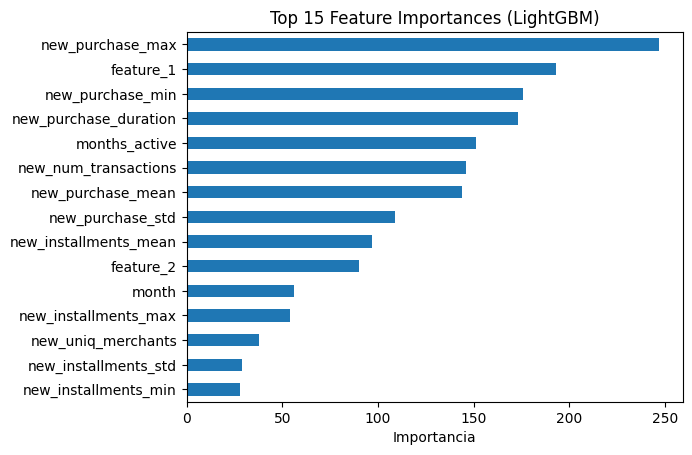

In [50]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


In [51]:
df_train_final = pl.read_parquet("src/train_processed_raw_features_new_agg.parquet")

In [52]:
# Ejemplo de imputación rápida (puedes ajustar a tu criterio)
df_train_final = df_train_final.with_columns([
    pl.col("new_purchase_mean").fill_null(0),
    pl.col("new_purchase_std").fill_null(0),
    pl.col("new_purchase_min").fill_null(0),
    pl.col("new_purchase_max").fill_null(0),
    pl.col("new_installments_mean").fill_null(0),
    pl.col("new_installments_std").fill_null(0),
    pl.col("new_installments_min").fill_null(0),
    pl.col("new_installments_max").fill_null(0),
    pl.col("new_num_transactions").fill_null(0),
    pl.col("new_uniq_merchants").fill_null(0),
    pl.col("new_uniq_cat1").fill_null(0),
    pl.col("new_uniq_cat2").fill_null(0),
    pl.col("new_uniq_cat3").fill_null(0),
    pl.col("new_purchase_duration").fill_null(0),
    # Las fechas puedes llenarlas con la mínima fecha posible, o simplemente no usarlas para el modelo directo
])


In [53]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train_final.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                   1.000000
year                     0.040341
month                    0.031512
new_purchase_min        -0.004732
feature_2               -0.006242
feature_3               -0.008125
feature_1               -0.014251
new_installments_min    -0.014781
new_purchase_duration   -0.027060
new_installments_max    -0.037367
new_purchase_mean       -0.038811
new_installments_std    -0.044415
new_installments_mean   -0.044753
new_uniq_cat3           -0.045213
new_uniq_merchants      -0.047194
new_num_transactions    -0.047268
new_uniq_cat2           -0.047399
new_uniq_cat1           -0.050179
months_active           -0.050453
new_purchase_max        -0.055329
new_purchase_std        -0.058536
Name: target, dtype: float64


In [54]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'new_first_purchase', 'new_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1852
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 20
[LightGBM] [Info] Start training from score -0.392633
new_purchase_duration    147
months_active            145
new_purchase_min         122
new_purchase_max         122
new_num_transactions      94
new_purchase_std          81
new_purchase_mean         79
new_installments_mean     75
feature_1                 66
month                     54
feature_2                 44
new_uniq_cat1             32
new_installments_std      29
new_installments_min      27
new_uniq_merchants        23
new_installments_max      21
year                      15
feature_3                 14
new_uniq_cat2              9
new_uniq_cat3              1
dtype: int32

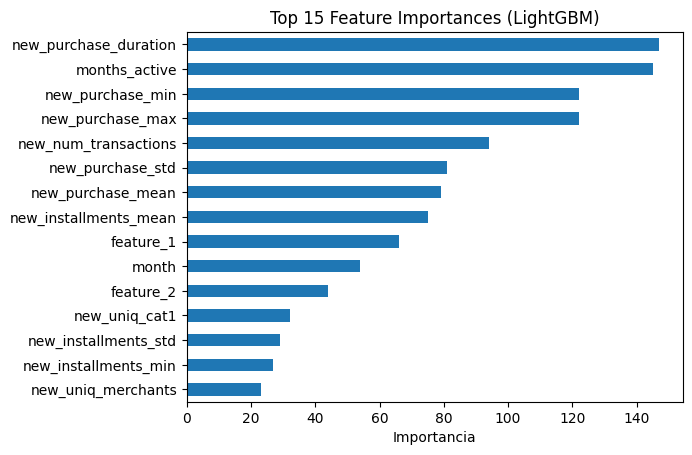

In [55]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


Al comparar el desempeño y la importancia de variables en modelos entrenados con y sin outliers, encontramos que la eliminación de valores extremos mejora significativamente la métrica de error (RMSE), reduce el sesgo del modelo y otorga mayor estabilidad a las variables explicativas. Las features derivadas de transacciones nuevas resultan ser las más relevantes, reforzando la hipótesis de que la actividad reciente es clave para anticipar la lealtad del cliente. Esta evidencia respalda la decisión de limpiar outliers para obtener modelos más interpretables y útiles en la práctica comercial.

In [10]:
import polars as pl

merchants_path = "src/merchants.csv"  # Usa la ruta donde subiste el archivo
df_merchants = pl.read_csv(merchants_path)

# Ver número de filas y columnas
print("Shape:", df_merchants.shape)

# Ver los nombres y tipos de todas las columnas
print("Schema:", df_merchants.schema)

# Ver las primeras 10 filas para ejemplos de valores
print(df_merchants.head(10))

# Verifica cuántos valores nulos hay por columna
print(df_merchants.null_count())



Shape: (334696, 22)
Schema: Schema([('merchant_id', String), ('merchant_group_id', Int64), ('merchant_category_id', Int64), ('subsector_id', Int64), ('numerical_1', Float64), ('numerical_2', Float64), ('category_1', String), ('most_recent_sales_range', String), ('most_recent_purchases_range', String), ('avg_sales_lag3', Float64), ('avg_purchases_lag3', Float64), ('active_months_lag3', Int64), ('avg_sales_lag6', Float64), ('avg_purchases_lag6', Float64), ('active_months_lag6', Int64), ('avg_sales_lag12', Float64), ('avg_purchases_lag12', Float64), ('active_months_lag12', Int64), ('category_4', String), ('city_id', Int64), ('state_id', Int64), ('category_2', Float64)])
shape: (10, 22)
┌─────────────────┬───────────────────┬──────────────────────┬──────────────┬─────────────┬─────────────┬────────────┬─────────────────────────┬─────────────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────

In [18]:
# Leer historical_transactions en lazy (scan_csv)
hist_path = "src/historical_transactions.csv"
df_hist = pl.scan_csv(hist_path)

# Leer merchants.csv en memoria
df_merchants = pl.read_csv(merchants_path)

# Leer merchants en modo LazyFrame
df_merchants_lazy = df_merchants.lazy()

# Unir por merchant_id (LEFT JOIN)
df_hist_enriched = df_hist.join(df_merchants_lazy, on="merchant_id", how="left")

# Agrega features por card_id
features_merchants_hist = df_hist_enriched.group_by("card_id").agg([
    pl.col("avg_sales_lag3").mean().alias("hist_merch_avg_sales_lag3_mean"),
    pl.col("avg_sales_lag3").std().alias("hist_merch_avg_sales_lag3_std"),
    pl.col("avg_purchases_lag3").mean().alias("hist_merch_avg_purch_lag3_mean"),
    pl.col("avg_purchases_lag3").std().alias("hist_merch_avg_purch_lag3_std"),
    pl.col("merchant_category_id").n_unique().alias("hist_merch_n_categories"),
    pl.col("merchant_group_id").n_unique().alias("hist_merch_n_groups"),
    pl.col("subsector_id").n_unique().alias("hist_merch_n_subsectors"),
    pl.col("numerical_1").mean().alias("hist_merch_num1_mean"),
    pl.col("numerical_2").mean().alias("hist_merch_num2_mean"),
    pl.col("category_1").value_counts().alias("hist_merch_cat1_counts"),
    pl.col("category_4").value_counts().alias("hist_merch_cat4_counts"),
    pl.col("most_recent_sales_range").value_counts().alias("hist_merch_sales_range_counts"),
    pl.col("most_recent_purchases_range").value_counts().alias("hist_merch_purch_range_counts"),
])

features_merchants_hist = features_merchants_hist.collect()
print(features_merchants_hist.head())


shape: (5, 14)
┌─────────────────┬────────────────────────────────┬───────────────────────────────┬────────────────────────────────┬───────────────────────────────┬─────────────────────────┬─────────────────────┬─────────────────────────┬──────────────────────┬──────────────────────┬────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ card_id         ┆ hist_merch_avg_sales_lag3_mean ┆ hist_merch_avg_sales_lag3_std ┆ hist_merch_avg_purch_lag3_mean ┆ hist_merch_avg_purch_lag3_std ┆ hist_merch_n_categories ┆ hist_merch_n_groups ┆ hist_merch_n_subsectors ┆ hist_merch_num1_mean ┆ hist_merch_num2_mean ┆ hist_merch_cat1_counts ┆ hist_merch_cat4_counts          ┆ hist_merch_sales_range_counts   ┆ hist_merch_purch_range_counts   │
│ ---             ┆ ---                            ┆ ---                           ┆ ---                            ┆ ---                           ┆ ---                     ┆ ---            

In [33]:
import polars as pl

# Rutas
new_path = "src/new_merchant_transactions.csv"
merchants_path = "src/merchants.csv"

# Carga transacciones nuevas y merchants
df_new = pl.scan_csv(new_path)
df_merchants = pl.read_csv(merchants_path)

df_merchants_lazy = df_merchants.lazy()

# Une transacciones nuevas con merchants
df_new_enriched = df_new.join(df_merchants_lazy, on="merchant_id", how="left")

# Features agregados por tarjeta (card_id)
features_merchants_new = df_new_enriched.group_by("card_id").agg([
    pl.col("avg_sales_lag3").mean().alias("new_merch_avg_sales_lag3_mean"),
    pl.col("avg_sales_lag3").std().alias("new_merch_avg_sales_lag3_std"),
    pl.col("avg_purchases_lag3").mean().alias("new_merch_avg_purch_lag3_mean"),
    pl.col("avg_purchases_lag3").std().alias("new_merch_avg_purch_lag3_std"),
    pl.col("merchant_category_id").n_unique().alias("new_merch_n_categories"),
    pl.col("merchant_group_id").n_unique().alias("new_merch_n_groups"),
    pl.col("subsector_id").n_unique().alias("new_merch_n_subsectors"),
    pl.col("numerical_1").mean().alias("new_merch_num1_mean"),
    pl.col("numerical_2").mean().alias("new_merch_num2_mean"),
    pl.col("category_1").value_counts().alias("new_merch_cat1_counts"),
    pl.col("category_4").value_counts().alias("new_merch_cat4_counts"),
    pl.col("most_recent_sales_range").value_counts().alias("new_merch_sales_range_counts"),
    pl.col("most_recent_purchases_range").value_counts().alias("new_merch_purch_range_counts"),
])

features_merchants_new = features_merchants_new.collect()
print(features_merchants_new.head())


shape: (5, 14)
┌─────────────────┬───────────────────────────────┬──────────────────────────────┬───────────────────────────────┬──────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────────┬───────────────────────┬───────────────────────┬───────────────────────────────┬───────────────────────────────┐
│ card_id         ┆ new_merch_avg_sales_lag3_mean ┆ new_merch_avg_sales_lag3_std ┆ new_merch_avg_purch_lag3_mean ┆ new_merch_avg_purch_lag3_std ┆ new_merch_n_categories ┆ new_merch_n_groups ┆ new_merch_n_subsectors ┆ new_merch_num1_mean ┆ new_merch_num2_mean ┆ new_merch_cat1_counts ┆ new_merch_cat4_counts ┆ new_merch_sales_range_counts  ┆ new_merch_purch_range_counts  │
│ ---             ┆ ---                           ┆ ---                          ┆ ---                           ┆ ---                          ┆ ---                    ┆ ---                ┆ ---                    ┆ ---                 ┆ 

In [15]:
df_train_raw = pl.read_parquet("src/train_processed.parquet")

In [27]:
df_train_final = df_train_raw.join(features_merchants_hist, on="card_id", how="left")

In [28]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [29]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "hist_cat1_")).alias("hist_merch_cat1_props"),
    pl.col("hist_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "hist_cat4_")).alias("hist_merch_cat4_props"),
    pl.col("hist_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "hist_salesrange_")).alias("hist_merch_sales_range_props"),
    pl.col("hist_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "hist_purchrange_")).alias("hist_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [30]:
df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_props").struct.unnest(),
    pl.col("hist_merch_cat4_props").struct.unnest(),
    pl.col("hist_merch_sales_range_props").struct.unnest(),
    pl.col("hist_merch_purch_range_props").struct.unnest(),
])


In [31]:
df_train_final = df_train_final.fill_null(0)

In [32]:
df_train_final.write_parquet("src/train_processed_raw_features_hist_agg_merchant.parquet")

In [1]:
import polars as pl

In [10]:
df_train_final = pl.read_parquet("src/train_processed_raw_features_hist_agg_merchant.parquet")

In [11]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [12]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [37]:
print(X.select_dtypes(exclude=["number", "bool"]).columns)

Index(['hist_merch_cat1_counts', 'hist_merch_cat4_counts',
       'hist_merch_sales_range_counts', 'hist_merch_purch_range_counts',
       'hist_merch_cat1_props', 'hist_merch_cat4_props',
       'hist_merch_sales_range_props', 'hist_merch_purch_range_props'],
      dtype='object')


In [32]:
X.columns

Index(['feature_1', 'feature_2', 'feature_3', 'year', 'month', 'months_active',
       'hist_merch_avg_sales_lag3_mean', 'hist_merch_avg_sales_lag3_std',
       'hist_merch_avg_purch_lag3_mean', 'hist_merch_avg_purch_lag3_std',
       'hist_merch_n_categories', 'hist_merch_n_groups',
       'hist_merch_n_subsectors', 'hist_merch_num1_mean',
       'hist_merch_num2_mean', 'hist_cat1_Y', 'hist_cat1_N', 'hist_cat1_null',
       'hist_cat4_Y', 'hist_cat4_N', 'hist_cat4_null', 'hist_salesrange_A',
       'hist_salesrange_B', 'hist_salesrange_C', 'hist_salesrange_D',
       'hist_salesrange_E', 'hist_salesrange_null', 'hist_purchrange_A',
       'hist_purchrange_B', 'hist_purchrange_C', 'hist_purchrange_D',
       'hist_purchrange_E', 'hist_purchrange_null'],
      dtype='object')

In [7]:
import numpy as np

In [13]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1955
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 15
[LightGBM] [Info] Start training from score -0.392633
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[15]	valid_0's l2: 14.9525
RMSE validación: 3.86685


months_active                     74
hist_merch_num1_mean              44
hist_merch_avg_purch_lag3_mean    41
hist_merch_n_groups               40
hist_merch_avg_sales_lag3_std     37
hist_merch_num2_mean              35
hist_merch_n_categories           34
hist_merch_avg_sales_lag3_mean    32
hist_merch_n_subsectors           24
feature_1                         23
hist_merch_avg_purch_lag3_std     23
feature_2                         22
month                             13
feature_3                          4
year                               4
hist_cat1_Y                        0
hist_cat1_N                        0
hist_cat1_null                     0
hist_cat4_Y                        0
hist_cat4_N                        0
dtype: int32


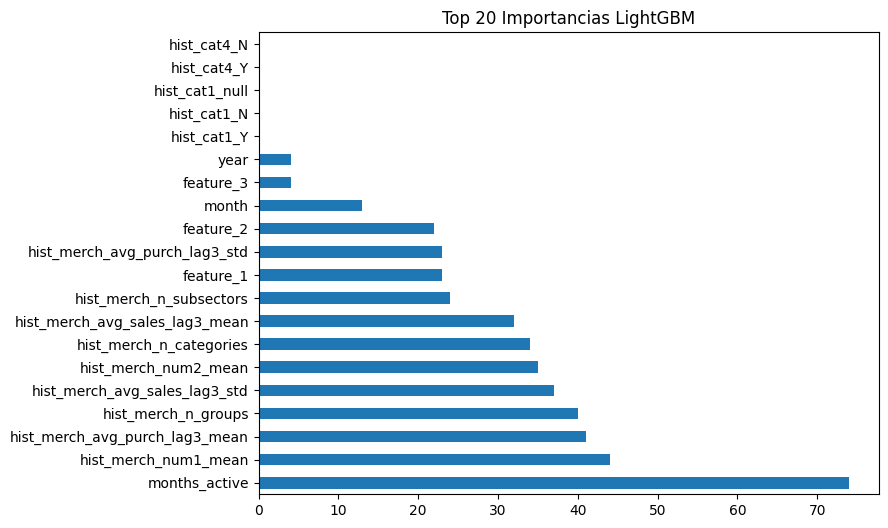

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [19]:
dr_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [20]:
df_train_final = dr_train_clean.join(features_merchants_hist, on="card_id", how="left")

In [21]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [22]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "hist_cat1_")).alias("hist_merch_cat1_props"),
    pl.col("hist_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "hist_cat4_")).alias("hist_merch_cat4_props"),
    pl.col("hist_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "hist_salesrange_")).alias("hist_merch_sales_range_props"),
    pl.col("hist_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "hist_purchrange_")).alias("hist_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [23]:
df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_props").struct.unnest(),
    pl.col("hist_merch_cat4_props").struct.unnest(),
    pl.col("hist_merch_sales_range_props").struct.unnest(),
    pl.col("hist_merch_purch_range_props").struct.unnest(),
])


In [24]:
df_train_final = df_train_final.fill_null(0)

In [25]:
df_train_final.write_parquet("src/train_processed_clean_features_hist_agg_merchant.parquet")

In [26]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [27]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [28]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 15
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's l2: 2.88977
RMSE validación: 1.69993


hist_merch_avg_purch_lag3_std     101
hist_merch_num1_mean              100
hist_merch_avg_purch_lag3_mean     86
hist_merch_num2_mean               86
hist_merch_avg_sales_lag3_std      85
hist_merch_avg_sales_lag3_mean     85
months_active                      82
hist_merch_n_groups                76
month                              66
hist_merch_n_categories            59
hist_merch_n_subsectors            44
feature_1                          28
feature_2                          20
feature_3                           8
year                                4
hist_cat1_Y                         0
hist_cat1_N                         0
hist_cat1_null                      0
hist_cat4_Y                         0
hist_cat4_N                         0
dtype: int32


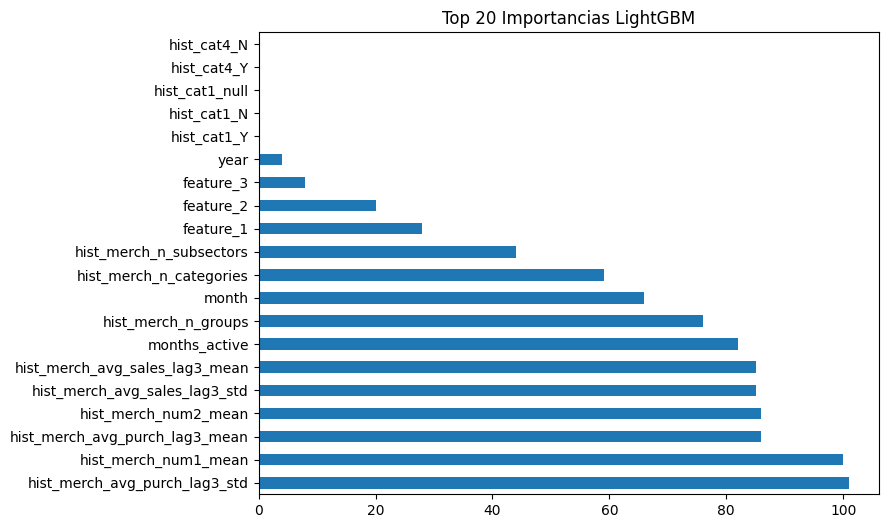

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [ ]:
import polars as pl

merchants_path = "src/merchants.csv"  # Usa la ruta donde subiste el archivo
df_merchants = pl.read_csv(merchants_path)

# Ver número de filas y columnas
print("Shape:", df_merchants.shape)

# Ver los nombres y tipos de todas las columnas
print("Schema:", df_merchants.schema)

# Ver las primeras 10 filas para ejemplos de valores
print(df_merchants.head(10))

# Verifica cuántos valores nulos hay por columna
print(df_merchants.null_count())



Shape: (334696, 22)
Schema: Schema([('merchant_id', String), ('merchant_group_id', Int64), ('merchant_category_id', Int64), ('subsector_id', Int64), ('numerical_1', Float64), ('numerical_2', Float64), ('category_1', String), ('most_recent_sales_range', String), ('most_recent_purchases_range', String), ('avg_sales_lag3', Float64), ('avg_purchases_lag3', Float64), ('active_months_lag3', Int64), ('avg_sales_lag6', Float64), ('avg_purchases_lag6', Float64), ('active_months_lag6', Int64), ('avg_sales_lag12', Float64), ('avg_purchases_lag12', Float64), ('active_months_lag12', Int64), ('category_4', String), ('city_id', Int64), ('state_id', Int64), ('category_2', Float64)])
shape: (10, 22)
┌─────────────────┬───────────────────┬──────────────────────┬──────────────┬─────────────┬─────────────┬────────────┬─────────────────────────┬─────────────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────

In [62]:
df_train_raw = pl.read_parquet("src/train_processed.parquet")

In [63]:
df_train_final = df_train_raw.join(features_merchants_new, on="card_id", how="left")

In [64]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [65]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "new_cat1_")).alias("new_merch_cat1_props"),
    pl.col("new_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "new_cat4_")).alias("new_merch_cat4_props"),
    pl.col("new_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "new_salesrange_")).alias("new_merch_sales_range_props"),
    pl.col("new_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "new_purchrange_")).alias("new_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [66]:
df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_props").struct.unnest(),
    pl.col("new_merch_cat4_props").struct.unnest(),
    pl.col("new_merch_sales_range_props").struct.unnest(),
    pl.col("new_merch_purch_range_props").struct.unnest(),
])


In [67]:
df_train_final = df_train_final.fill_null(0)

In [68]:
df_train_final.write_parquet("src/train_processed_raw_features_new_agg_merchant.parquet")

In [45]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [46]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [47]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 15
[LightGBM] [Info] Start training from score -0.392633
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[33]	valid_0's l2: 14.8383
RMSE validación: 3.85206


months_active                    165
new_merch_avg_purch_lag3_mean    111
new_merch_num1_mean               98
new_merch_avg_sales_lag3_mean     97
feature_1                         74
new_merch_avg_sales_lag3_std      73
new_merch_avg_purch_lag3_std      72
new_merch_num2_mean               62
month                             61
new_merch_n_categories            61
feature_2                         56
new_merch_n_subsectors            20
new_merch_n_groups                20
year                              13
feature_3                          7
new_cat1_Y                         0
new_cat1_N                         0
new_cat1_null                      0
new_cat4_Y                         0
new_cat4_N                         0
dtype: int32


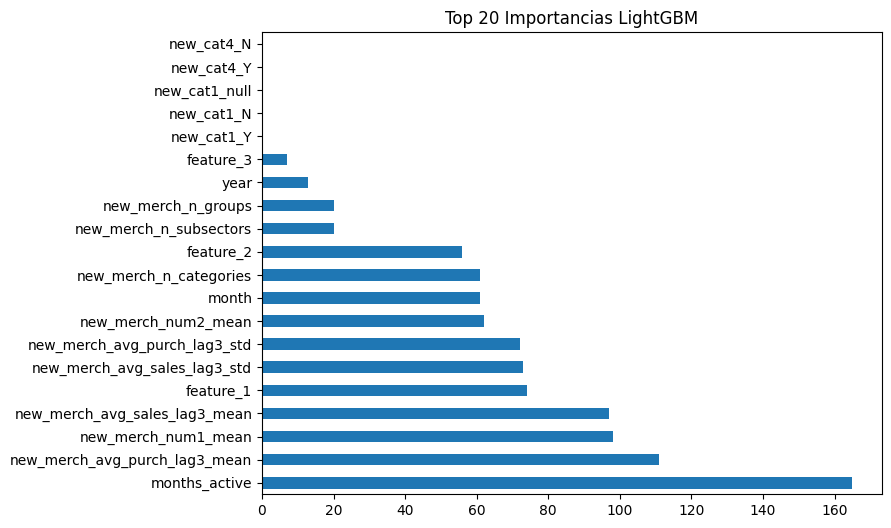

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [50]:
df_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [51]:
df_train_final = df_train_clean.join(features_merchants_new, on="card_id", how="left")

In [52]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [53]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "new_cat1_")).alias("new_merch_cat1_props"),
    pl.col("new_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "new_cat4_")).alias("new_merch_cat4_props"),
    pl.col("new_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "new_salesrange_")).alias("new_merch_sales_range_props"),
    pl.col("new_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "new_purchrange_")).alias("new_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [54]:
df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_props").struct.unnest(),
    pl.col("new_merch_cat4_props").struct.unnest(),
    pl.col("new_merch_sales_range_props").struct.unnest(),
    pl.col("new_merch_purch_range_props").struct.unnest(),
])


In [55]:
df_train_final = df_train_final.fill_null(0)

In [60]:
df_train_final.write_parquet("src/train_processed_clean_features_new_agg_merchant.parquet")

In [56]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [57]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [58]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 15
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[68]	valid_0's l2: 2.65201
RMSE validación: 1.62850


months_active                    262
new_merch_avg_sales_lag3_mean    252
new_merch_avg_purch_lag3_mean    249
new_merch_avg_purch_lag3_std     182
new_merch_n_categories           154
new_merch_num1_mean              154
new_merch_avg_sales_lag3_std     152
feature_1                        144
new_merch_num2_mean              121
month                            114
feature_2                         82
new_merch_n_groups                75
feature_3                         49
new_merch_n_subsectors            37
year                              13
new_cat1_Y                         0
new_cat1_N                         0
new_cat1_null                      0
new_cat4_Y                         0
new_cat4_N                         0
dtype: int32


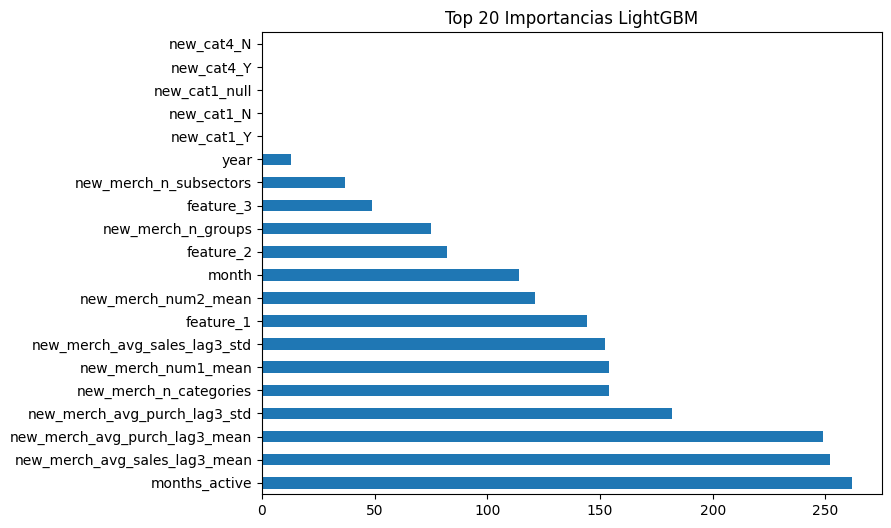

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [69]:
vdf_clean_hist_trx_features = pl.read_parquet("src/train_processed_clean_features_agg.parquet")

In [70]:
vdf_clean_hist_merchant_features = pl.read_parquet("src/train_processed_clean_features_hist_agg_merchant.parquet")

In [112]:
vdf_hist_clean_total = vdf_clean_hist_trx_features.join(
    vdf_clean_hist_merchant_features, on="card_id", how="left"
)

In [113]:
vdf_hist_clean_total = vdf_hist_clean_total.fill_null(0)

In [82]:
# Contar si algún card_id se repite
dupes = vdf_hist_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)
print(f"Tarjetas duplicadas: {dupes.shape[0]}")
if dupes.shape[0] > 0:
    print(dupes)


Tarjetas duplicadas: 0


C:\Users\Paul\AppData\Local\Temp\ipykernel_23120\3893832931.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  dupes = vdf_hist_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)


In [83]:
from collections import Counter
col_counts = Counter(vdf_hist_clean_total.columns)
dupe_cols = [col for col, cnt in col_counts.items() if cnt > 1]
if dupe_cols:
    print("Columnas duplicadas:", dupe_cols)
else:
    print("No hay columnas duplicadas.")


No hay columnas duplicadas.


In [85]:
print(vdf_hist_clean_total.null_count())


shape: (1, 68)
┌────────────────────┬─────────┬───────────┬───────────┬───────────┬────────┬──────┬───────┬───────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬────────────────────┬─────────────────────┬────────────────┬────────────────┬────────────────┬────────────────────────┬───┬────────────────────────┬───────────────────────────────┬───────────────────────────────┬───────────────────────┬───────────────────────┬──────────────────────────────┬──────────────────────────────┬─────────────┬─────────────┬────────────────┬─────────────┬─────────────┬────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬──────────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬──────────────────

In [92]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in vdf_hist_clean_total.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = vdf_hist_clean_total.select(good_features).to_pandas()
y = vdf_hist_clean_total["target"].to_pandas()


In [93]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)

# Calcula RMSE de la manera compatible con cualquier versión de sklearn
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Top 20 features más importantes:\n", importances.sort_values(ascending=False).head(20))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4374
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 35
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[92]	valid_0's l2: 2.8681
RMSE validación: 1.69355
Top 20 features más importantes:
 hist_purchase_duration            347
hist_num_transactions             251
hist_purchase_mean                190
hist_purchase_min                 188
months_active                     170
hist_purchase_std                 146
hist_purchase_max                 136
hist_merch_avg_sales_lag3_mean    124
hist_installments_std             122
hist_merch_avg_sales_lag3_std     116
hist_merch_num1_mean              107
hist_merch_avg_purch_lag3_std     104
hist_installments_m

In [94]:
vdf_clean_new_trx_features = pl.read_parquet("src/train_processed_clean_features_new_agg.parquet")

In [95]:
vdf_clean_new_merchant_features = pl.read_parquet("src/train_processed_clean_features_new_agg_merchant.parquet")

In [110]:
vdf_new_clean_total = vdf_clean_new_trx_features.join(
    vdf_clean_new_merchant_features, on="card_id", how="left"
)

In [111]:
vdf_new_clean_total = vdf_new_clean_total.fill_null(0)

In [98]:
# Contar si algún card_id se repite
dupes = vdf_new_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)
print(f"Tarjetas duplicadas: {dupes.shape[0]}")
if dupes.shape[0] > 0:
    print(dupes)


Tarjetas duplicadas: 0


C:\Users\Paul\AppData\Local\Temp\ipykernel_23120\4290906095.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  dupes = vdf_new_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)


In [99]:
from collections import Counter
col_counts = Counter(vdf_new_clean_total.columns)
dupe_cols = [col for col, cnt in col_counts.items() if cnt > 1]
if dupe_cols:
    print("Columnas duplicadas:", dupe_cols)
else:
    print("No hay columnas duplicadas.")


No hay columnas duplicadas.


In [100]:
print(vdf_new_clean_total.null_count())


shape: (1, 68)
┌────────────────────┬─────────┬───────────┬───────────┬───────────┬────────┬──────┬───────┬───────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┬───┬───────────────────────┬──────────────────────────────┬──────────────────────────────┬──────────────────────┬──────────────────────┬─────────────────────────────┬─────────────────────────────┬────────────┬────────────┬───────────────┬────────────┬────────────┬───────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────────┐
│ first_active_month ┆ card_id ┆ fe

In [101]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in vdf_new_clean_total.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = vdf_new_clean_total.select(good_features).to_pandas()
y = vdf_new_clean_total["target"].to_pandas()


In [102]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)

# Calcula RMSE de la manera compatible con cualquier versión de sklearn
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Top 20 features más importantes:\n", importances.sort_values(ascending=False).head(20))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3610
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 35
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[111]	valid_0's l2: 2.51092
RMSE validación: 1.58459
Top 20 features más importantes:
 new_purchase_max                 395
feature_1                        363
new_purchase_duration            263
months_active                    244
new_purchase_mean                228
new_purchase_min                 207
new_purchase_std                 166
new_num_transactions             141
new_installments_mean            138
feature_2                        135
new_merch_avg_purch_lag3_mean    128
new_merch_avg_sales_lag3_mean    115
new_merch_avg_purch_lag3_std 

In [114]:
# Revisar columnas que están en ambos DFs y NO son 'card_id'
cols_hist = set(vdf_hist_clean_total.columns)
cols_new = set(vdf_new_clean_total.columns)
overlap = (cols_hist & cols_new) - {"card_id"} - {"target", "first_active_month"}

print("Columnas repetidas que no deberían estar:", overlap)


Columnas repetidas que no deberían estar: {'feature_3', 'year', 'month_right', 'feature_1_right', 'months_active', 'feature_3_right', 'months_active_right', 'first_active_month_right', 'feature_2_right', 'feature_1', 'month', 'target_right', 'year_right', 'feature_2'}


In [115]:
cols_to_drop_hist = [col for col in vdf_hist_clean_total.columns if col in overlap and col != "card_id"]
cols_to_drop_new = [col for col in vdf_new_clean_total.columns if col in overlap and col != "card_id"]

vdf_hist_clean_total = vdf_hist_clean_total.drop(cols_to_drop_hist)
vdf_new_clean_total = vdf_new_clean_total.drop(cols_to_drop_new)


In [116]:
df_final = vdf_hist_clean_total.join(vdf_new_clean_total, on="card_id", how="outer").fill_null(0)

C:\Users\Paul\AppData\Local\Temp\ipykernel_23120\1029196349.py:1: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  df_final = vdf_hist_clean_total.join(vdf_new_clean_total, on="card_id", how="outer").fill_null(0)


In [ ]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [3]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()


In [9]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)

# Calcula RMSE de la manera compatible con cualquier versión de sklearn
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Top 20 features más importantes:\n", importances.sort_values(ascending=False).head(20))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7552
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 46
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[252]	valid_0's l2: 2.43769
RMSE validación: 1.56131
Top 20 features más importantes:
 hist_purchase_mean                566
new_purchase_max                  554
hist_num_transactions             542
hist_purchase_duration            460
hist_purchase_min                 373
new_purchase_mean                 361
hist_merch_n_groups               352
hist_purchase_max                 280
new_purchase_duration             259
hist_uniq_merchants               246
new_purchase_min                  220
hist_purchase_std                 199
new_num_transacti

In [ ]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [ ]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()

In [11]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Supongamos que ya tienes tus datos
# X, y = tus features y target

# Entrena modelo base para obtener la importancia de features
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_base = LGBMRegressor(random_state=42)
modelo_base.fit(X_train, y_train)
importancias = pd.Series(modelo_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Número de features a probar
top_n_list = [10, 15, 20, 30, 40]

resultados = []

for top_n in top_n_list:
    top_features = importancias.index[:top_n]
    print(f"\nProbando con las top {top_n} features: {list(top_features)}")
    
    # Subset de datos
    X_train_sub = X_train[top_features]
    X_val_sub = X_val[top_features]
    
    # Entrena un modelo nuevo solo con esas features
    modelo = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
    modelo.fit(X_train_sub, y_train)
    
    # Predicción y RMSE
    y_pred = modelo.predict(X_val_sub)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    resultados.append((top_n, rmse))
    print(f"RMSE validación (top {top_n}): {rmse:.5f}")

# Mostrar resumen final
print("\n--- Resultados finales ---")
for n, score in resultados:
    print(f"Top {n} features: RMSE = {score:.5f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7552
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 46
[LightGBM] [Info] Start training from score -0.028637

Probando con las top 10 features: ['hist_purchase_mean', 'new_purchase_max', 'hist_num_transactions', 'hist_purchase_duration', 'hist_merch_n_groups', 'new_purchase_mean', 'hist_purchase_min', 'new_purchase_duration', 'hist_purchase_max', 'hist_purchase_std']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002038 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2277
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 10
[LightGBM] [Info] Start training from score -0.028637
RMSE validación (top 10): 1.57498

Probando con las

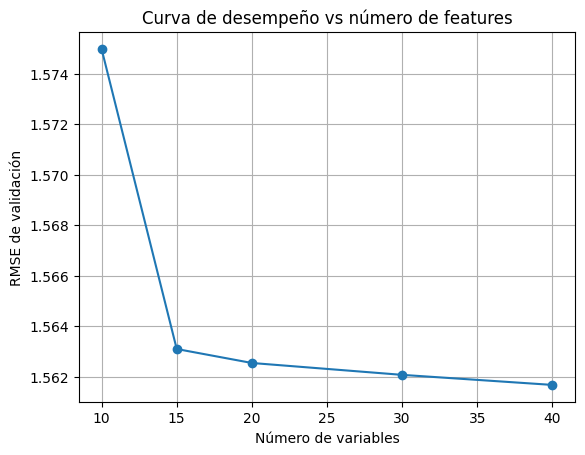

In [14]:
import matplotlib.pyplot as plt

n_features = [x[0] for x in resultados]
rmse_scores = [x[1] for x in resultados]

plt.plot(n_features, rmse_scores, marker='o')
plt.xlabel('Número de variables')
plt.ylabel('RMSE de validación')
plt.title('Curva de desempeño vs número de features')
plt.grid()
plt.show()


In [121]:
df_final.write_parquet("src/train_processed_final_v4.parquet")

In [1]:
import polars as pl

In [2]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [ ]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()


In [17]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Si tienes pandas DataFrames:
# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)

model_cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    random_state=42,
    verbose=50,  # muestra progreso cada 50 iteraciones
    early_stopping_rounds=30
)
model_cb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred_cb = model_cb.predict(X_val)
rmse_cb = np.sqrt(mean_squared_error(y_val, y_pred_cb))
print(f"CatBoost RMSE validación: {rmse_cb:.5f}")


0:	learn: 1.7132667	test: 1.6940041	best: 1.6940041 (0)	total: 10.7ms	remaining: 10.7s
50:	learn: 1.6070497	test: 1.5881172	best: 1.5881172 (50)	total: 511ms	remaining: 9.5s
100:	learn: 1.5919305	test: 1.5747279	best: 1.5747279 (100)	total: 990ms	remaining: 8.81s
150:	learn: 1.5845403	test: 1.5693055	best: 1.5693055 (150)	total: 1.47s	remaining: 8.27s
200:	learn: 1.5793474	test: 1.5661353	best: 1.5661353 (200)	total: 1.97s	remaining: 7.82s
250:	learn: 1.5751275	test: 1.5642627	best: 1.5642627 (250)	total: 2.45s	remaining: 7.32s
300:	learn: 1.5708046	test: 1.5626512	best: 1.5626512 (300)	total: 2.93s	remaining: 6.81s
350:	learn: 1.5669361	test: 1.5616327	best: 1.5616327 (350)	total: 3.41s	remaining: 6.3s
400:	learn: 1.5636336	test: 1.5609459	best: 1.5609449 (399)	total: 3.89s	remaining: 5.82s
450:	learn: 1.5605860	test: 1.5604405	best: 1.5604280 (449)	total: 4.42s	remaining: 5.38s
500:	learn: 1.5576131	test: 1.5600497	best: 1.5600409 (499)	total: 4.91s	remaining: 4.89s
550:	learn: 1.554

In [ ]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [ ]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()


In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    verbosity=1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    # early_stopping_rounds=30,
    verbose=True
)

y_pred_xgb = model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
print(f"XGBoost RMSE validación: {rmse_xgb:.5f}")


[0]	validation_0-rmse:1.69232
[1]	validation_0-rmse:1.68312
[2]	validation_0-rmse:1.67464
[3]	validation_0-rmse:1.66696
[4]	validation_0-rmse:1.65975
[5]	validation_0-rmse:1.65337
[6]	validation_0-rmse:1.64733
[7]	validation_0-rmse:1.64199
[8]	validation_0-rmse:1.63684
[9]	validation_0-rmse:1.63243
[10]	validation_0-rmse:1.62821
[11]	validation_0-rmse:1.62450
[12]	validation_0-rmse:1.62085
[13]	validation_0-rmse:1.61767
[14]	validation_0-rmse:1.61475
[15]	validation_0-rmse:1.61205
[16]	validation_0-rmse:1.60950
[17]	validation_0-rmse:1.60690
[18]	validation_0-rmse:1.60478
[19]	validation_0-rmse:1.60271
[20]	validation_0-rmse:1.60063
[21]	validation_0-rmse:1.59870
[22]	validation_0-rmse:1.59691
[23]	validation_0-rmse:1.59536
[24]	validation_0-rmse:1.59399
[25]	validation_0-rmse:1.59256
[26]	validation_0-rmse:1.59095
[27]	validation_0-rmse:1.58975
[28]	validation_0-rmse:1.58862
[29]	validation_0-rmse:1.58752
[30]	validation_0-rmse:1.58652
[31]	validation_0-rmse:1.58551
[32]	validation_0-